# 2. EXPLORATORY DATA ANALYSIS
## Daily Customer Churn Predictor · VivaMarket Brasil

---

**INPUT:** `../data/interim/client_database_clean_YYYYMMDD.parquet` or `../data/raw/churn_sqlite_db.sqlite`  
*A cleaned customer-level base when available, otherwise the raw SQLite source used to rebuild the minimum analytical layer required for EDA.*

**OUTPUT:** Business-oriented exploratory insights, churn-rate framing, customer segmentation patterns, and temporal/cohort analysis to guide feature engineering and modeling.


---
## 2.1. STARTING SITUATION


NB01 established that the source database is structurally usable for churn modeling and that `customer_unique_id` must be the analytical customer key. The project now needs a deeper understanding of customer purchasing behavior, inactivity patterns and temporal dynamics before feature engineering begins.

At this point, the key analytical questions are:

- how concentrated customer value is across the base;
- what inactivity pattern is most consistent with a 90-day churn horizon;
- whether customer behavior is stable enough for temporal validation;
- which early segments deserve differentiated feature engineering and retention logic.


---
## 2.2. NOTEBOOK OBJECTIVE


- **Business objective:** understand customer behavior patterns that explain churn risk and retention opportunity in the VivaMarket Brasil marketplace.
- **Analytical objective:** formalize an initial 90-day churn definition, quantify churn incidence and identify the temporal/behavioral signals that should be engineered in NB03.
- **Notebook objective:** produce a clean exploratory layer with descriptive statistics, churn framing, cohort behavior and first-pass customer segmentation.

This notebook focuses on **explaining the data-generating behavior**, not on training models yet. The main deliverable is a clear set of insights and a stronger design basis for feature engineering.


---
## 2.3. INITIAL SETUP


**What is done**

We import the libraries required for exploratory analysis, plotting, logging and project-relative path management.

**Why it is done**

NB02 should remain reproducible across local execution, Colab and GitHub-driven collaboration. Logging is kept explicit so the analytical flow remains auditable and easier to debug.

**Expected result**

A stable execution environment that can load the cleaned interim dataset when present and fall back to the raw SQLite database otherwise.


In [1]:
import logging
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger(__name__)
logger.info('NB02 started: exploratory data analysis.')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', context='talk')


2026-04-29 16:29:45,884 | INFO | NB02 started: exploratory data analysis.


In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
PATH_DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
PATH_DATA_INTERIM = PROJECT_ROOT / 'data' / 'interim'
PATH_REPORTS = PROJECT_ROOT / 'reports'
DB_PATH = PATH_DATA_RAW / 'churn_sqlite_db.sqlite'

PATH_REPORTS.mkdir(parents=True, exist_ok=True)

logger.info('Project root resolved at %s', PROJECT_ROOT)
logger.info('Raw database path resolved at %s', DB_PATH)
assert DB_PATH.exists(), f'Missing SQLite source at {DB_PATH}'

interim_candidates = sorted(PATH_DATA_INTERIM.glob('client_database_clean_*.parquet')) if PATH_DATA_INTERIM.exists() else []
latest_interim_path = interim_candidates[-1] if interim_candidates else None
logger.info('Latest interim dataset found: %s', latest_interim_path)


2026-04-29 16:29:45,893 | INFO | Project root resolved at /data/.openclaw/workspace/projects/TFM/daily-customer-churn-predictor


2026-04-29 16:29:45,893 | INFO | Raw database path resolved at /data/.openclaw/workspace/projects/TFM/daily-customer-churn-predictor/data/raw/churn_sqlite_db.sqlite


2026-04-29 16:29:45,894 | INFO | Latest interim dataset found: None


---
## 2.4. DATA LOADING STRATEGY


**What is done**

We attempt to load the latest cleaned interim dataset. If it is not available yet, we rebuild the minimum analytical layer required for EDA directly from SQLite.

**Why it is done**

This keeps the notebook resilient during early project iterations and avoids blocking exploratory work while preserving reproducibility.

**Expected result**

A consistent `customer_level_df` dataframe plus an order-level history dataframe for churn, temporal and cohort analysis.


In [3]:
def load_orders_base(connection: sqlite3.Connection) -> pd.DataFrame:
    query = """
    SELECT
        o.order_id,
        o.customer_id,
        c.customer_unique_id,
        c.customer_state,
        o.order_status,
        o.order_purchase_timestamp,
        o.order_delivered_customer_date
    FROM orders o
    LEFT JOIN customers c
        ON o.customer_id = c.customer_id
    """
    df = pd.read_sql_query(query, connection)
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
    df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
    logger.info('Loaded orders base with %d rows.', len(df))
    return df


def load_order_value_base(connection: sqlite3.Connection) -> pd.DataFrame:
    query = """
    SELECT
        oi.order_id,
        SUM(oi.price) AS total_item_price,
        SUM(oi.freight_value) AS total_freight_value,
        COUNT(*) AS total_items_n,
        COUNT(DISTINCT oi.product_id) AS unique_products_n,
        COUNT(DISTINCT oi.seller_id) AS unique_sellers_n
    FROM order_items oi
    GROUP BY oi.order_id
    """
    df = pd.read_sql_query(query, connection)
    logger.info('Loaded order item aggregates with %d rows.', len(df))
    return df


def load_payment_base(connection: sqlite3.Connection) -> pd.DataFrame:
    query = """
    SELECT
        op.order_id,
        SUM(op.payment_value) AS total_payment_value,
        COUNT(*) AS payment_records_n,
        MAX(op.payment_installments) AS max_installments
    FROM order_payments op
    GROUP BY op.order_id
    """
    df = pd.read_sql_query(query, connection)
    logger.info('Loaded payment aggregates with %d rows.', len(df))
    return df


def load_review_base(connection: sqlite3.Connection) -> pd.DataFrame:
    query = """
    SELECT
        order_id,
        AVG(review_score) AS avg_review_score
    FROM order_reviews
    GROUP BY order_id
    """
    df = pd.read_sql_query(query, connection)
    logger.info('Loaded review aggregates with %d rows.', len(df))
    return df


In [4]:
try:
    conn = sqlite3.connect(DB_PATH)
    logger.info('SQLite connection established successfully.')
except Exception as exc:
    logger.error('Failed to connect to SQLite database: %s', exc)
    raise

orders_base_df = load_orders_base(conn)
order_value_df = load_order_value_base(conn)
payment_df = load_payment_base(conn)
review_df = load_review_base(conn)

orders_enriched_df = (
    orders_base_df
    .merge(order_value_df, on='order_id', how='left')
    .merge(payment_df, on='order_id', how='left')
    .merge(review_df, on='order_id', how='left')
)

orders_enriched_df['purchase_month'] = orders_enriched_df['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
orders_enriched_df['delivered_flag'] = (orders_enriched_df['order_status'] == 'delivered').astype(int)

logger.info('Orders enriched dataframe created with %d rows.', len(orders_enriched_df))
orders_enriched_df.head()


2026-04-29 16:29:45,907 | INFO | SQLite connection established successfully.


2026-04-29 16:29:47,063 | INFO | Loaded orders base with 99441 rows.


2026-04-29 16:29:47,371 | INFO | Loaded order item aggregates with 98666 rows.


2026-04-29 16:29:47,590 | INFO | Loaded payment aggregates with 99440 rows.


2026-04-29 16:29:47,731 | INFO | Loaded review aggregates with 98673 rows.


2026-04-29 16:29:47,858 | INFO | Orders enriched dataframe created with 99441 rows.


,order_id,customer_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_delivered_customer_date,total_item_price,total_freight_value,total_items_n,unique_products_n,unique_sellers_n,total_payment_value,payment_records_n,max_installments,avg_review_score,purchase_month,delivered_flag
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,SP,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,29.99,8.72,1.00,1.00,1.00,38.71,3.00,1.00,4.00,2017-10-01,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,BA,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,118.70,22.76,1.00,1.00,1.00,141.46,1.00,1.00,4.00,2018-07-01,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,GO,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,159.90,19.22,1.00,1.00,1.00,179.12,1.00,3.00,5.00,2018-08-01,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,RN,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,45.00,27.20,1.00,1.00,1.00,72.20,1.00,1.00,5.00,2017-11-01,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,SP,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,19.90,8.72,1.00,1.00,1.00,28.62,1.00,1.00,5.00,2018-02-01,1


In [5]:
if latest_interim_path is not None:
    try:
        customer_level_df = pd.read_parquet(latest_interim_path)
        logger.info('Loaded interim customer dataset from %s', latest_interim_path)
    except Exception as exc:
        logger.error('Failed to load interim parquet dataset: %s', exc)
        raise
else:
    customer_level_df = (
        orders_enriched_df
        .groupby('customer_unique_id', as_index=False)
        .agg(
            customer_state=('customer_state', 'last'),
            first_purchase_timestamp=('order_purchase_timestamp', 'min'),
            last_purchase_timestamp=('order_purchase_timestamp', 'max'),
            orders_n=('order_id', 'nunique'),
            delivered_orders_n=('delivered_flag', 'sum'),
            total_items_n=('total_items_n', 'sum'),
            total_payment_value=('total_payment_value', 'sum'),
            total_item_price=('total_item_price', 'sum'),
            total_freight_value=('total_freight_value', 'sum'),
            avg_review_score=('avg_review_score', 'mean'),
            max_installments=('max_installments', 'max')
        )
    )

    customer_level_df['customer_lifetime_days'] = (
        customer_level_df['last_purchase_timestamp'] - customer_level_df['first_purchase_timestamp']
    ).dt.days
    customer_level_df['avg_order_value'] = customer_level_df['total_payment_value'] / customer_level_df['orders_n']
    customer_level_df['avg_items_per_order'] = customer_level_df['total_items_n'] / customer_level_df['orders_n']
    logger.info('Interim parquet not found. Rebuilt customer-level dataset with %d rows.', len(customer_level_df))

customer_level_df.head()


2026-04-29 16:29:47,972 | INFO | Interim parquet not found. Rebuilt customer-level dataset with 96096 rows.


,customer_unique_id,customer_state,first_purchase_timestamp,last_purchase_timestamp,orders_n,delivered_orders_n,total_items_n,total_payment_value,total_item_price,total_freight_value,avg_review_score,max_installments,customer_lifetime_days,avg_order_value,avg_items_per_order
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,2018-05-10 10:56:27,2018-05-10 10:56:27,1,1,1.00,141.90,129.90,12.00,5.00,8.00,0,141.90,1.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,2018-05-07 11:11:27,2018-05-07 11:11:27,1,1,1.00,27.19,18.90,8.29,4.00,1.00,0,27.19,1.00
2,0000f46a3911fa3c0805444483337064,SC,2017-03-10 21:05:03,2017-03-10 21:05:03,1,1,1.00,86.22,69.00,17.22,3.00,8.00,0,86.22,1.00
3,0000f6ccb0745a6a4b88665a16c9f078,PA,2017-10-12 20:29:41,2017-10-12 20:29:41,1,1,1.00,43.62,25.99,17.63,4.00,4.00,0,43.62,1.00
4,0004aac84e0df4da2b147fca70cf8255,SP,2017-11-14 19:45:42,2017-11-14 19:45:42,1,1,1.00,196.89,180.00,16.89,5.00,6.00,0,196.89,1.00


---
## 2.5. DESCRIPTIVE CUSTOMER OVERVIEW


**What is done**

We quantify the size, activity and value distribution of the customer base.

**Why it is done**

Before defining churn, we need a grounded view of how concentrated purchasing behavior is and whether the dataset is dominated by one-time buyers, repeat customers or a mixed pattern.

**Expected result**

A baseline descriptive profile of the customer base that can later be contrasted against churn behavior.


In [6]:
customer_overview = pd.DataFrame({
    'metric': [
        'customers_n',
        'orders_mean',
        'orders_median',
        'avg_order_value_mean',
        'avg_review_score_mean',
        'customer_lifetime_days_median'
    ],
    'value': [
        customer_level_df['customer_unique_id'].nunique() if 'customer_unique_id' in customer_level_df.columns else len(customer_level_df),
        customer_level_df['orders_n'].mean(),
        customer_level_df['orders_n'].median(),
        customer_level_df['avg_order_value'].mean(),
        customer_level_df['avg_review_score'].mean(),
        customer_level_df['customer_lifetime_days'].median()
    ]
})

customer_overview


,metric,value
0,customers_n,"96,096.00"
1,orders_mean,1.03
2,orders_median,1.00
3,avg_order_value_mean,161.40
4,avg_review_score_mean,4.08
5,customer_lifetime_days_median,0.00


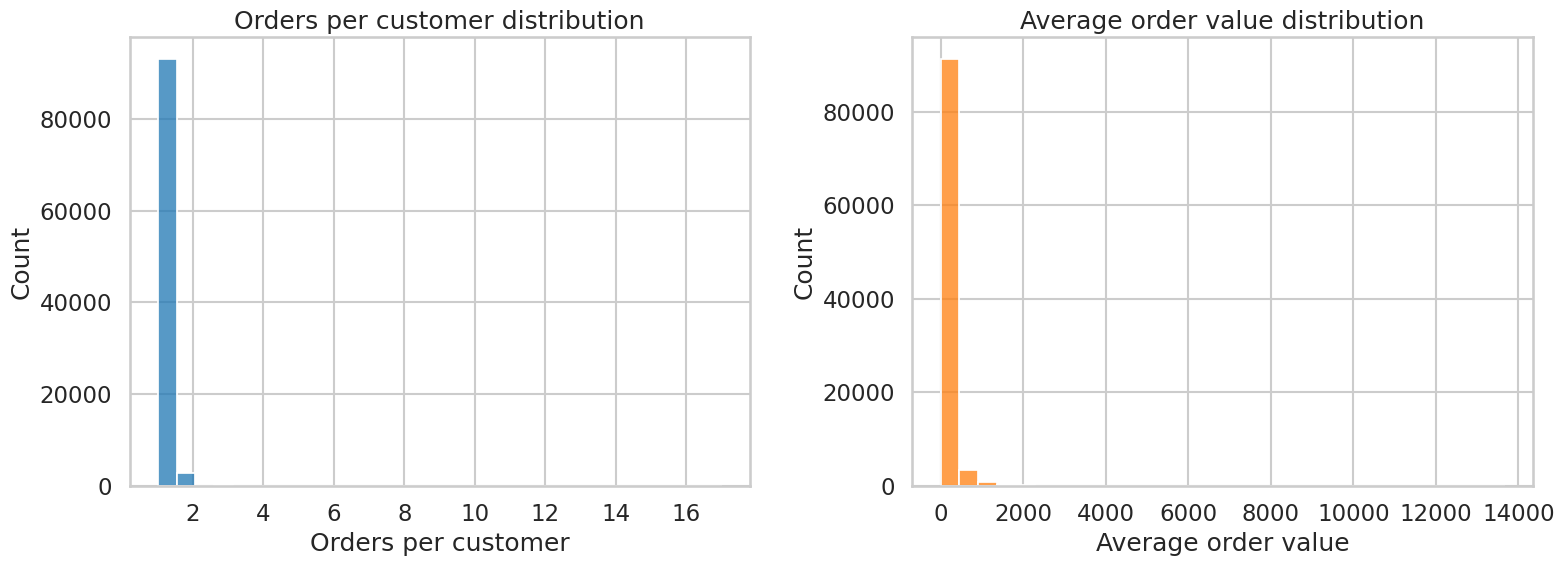

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(customer_level_df['orders_n'].fillna(0), bins=30, ax=axes[0], color='#1f77b4')
axes[0].set_title('Orders per customer distribution')
axes[0].set_xlabel('Orders per customer')

sns.histplot(customer_level_df['avg_order_value'].replace([np.inf, -np.inf], np.nan).dropna(), bins=30, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Average order value distribution')
axes[1].set_xlabel('Average order value')

plt.tight_layout()
plt.show()


---
## 2.6. INITIAL CHURN DEFINITION FOR A 90-DAY HORIZON


**What is done**

We define an initial churn proxy where a customer is considered churned if no additional purchase is observed within 90 days after the customer’s latest purchase, provided that the dataset offers enough future observation window.

**Why it is done**

The project needs a label aligned with the intended retention use case. A 90-day forward horizon is simple, business-interpretable and consistent with a daily scoring process.

**Expected result**

A first churn label, its estimated rate and a clear statement of the observation-window assumptions behind it.


In [8]:
analysis_end_date = orders_enriched_df['order_purchase_timestamp'].max()
label_horizon_days = 90

customer_churn_df = customer_level_df.copy()
customer_churn_df['analysis_end_date'] = analysis_end_date
customer_churn_df['days_since_last_purchase_at_dataset_end'] = (
    customer_churn_df['analysis_end_date'] - customer_churn_df['last_purchase_timestamp']
).dt.days
customer_churn_df['eligible_for_churn_label'] = (
    customer_churn_df['last_purchase_timestamp'] <= customer_churn_df['analysis_end_date'] - pd.Timedelta(days=label_horizon_days)
)
customer_churn_df['churn_90d_flag'] = np.where(
    customer_churn_df['eligible_for_churn_label']
    & (customer_churn_df['days_since_last_purchase_at_dataset_end'] >= label_horizon_days),
    1,
    0
)

churn_summary = pd.DataFrame({
    'metric': [
        'analysis_end_date',
        'eligible_customers_n',
        'churned_customers_n',
        'non_churned_customers_n',
        'churn_rate_eligible_base'
    ],
    'value': [
        analysis_end_date,
        int(customer_churn_df['eligible_for_churn_label'].sum()),
        int(customer_churn_df.loc[customer_churn_df['eligible_for_churn_label'], 'churn_90d_flag'].sum()),
        int(customer_churn_df['eligible_for_churn_label'].sum() - customer_churn_df.loc[customer_churn_df['eligible_for_churn_label'], 'churn_90d_flag'].sum()),
        customer_churn_df.loc[customer_churn_df['eligible_for_churn_label'], 'churn_90d_flag'].mean()
    ]
})

churn_summary


,metric,value
0,analysis_end_date,2018-10-17 17:30:18
1,eligible_customers_n,86684
2,churned_customers_n,86684
3,non_churned_customers_n,0
4,churn_rate_eligible_base,1.00


2026-04-29 16:29:48,382 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/tmp/ipykernel_11217/2267779099.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_11217/2267779099.py:4: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(
2026-04-29 16:29:48,387 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


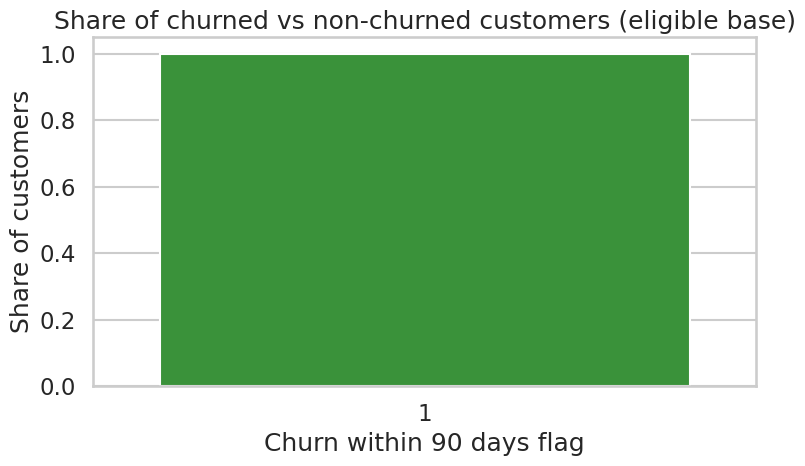

In [9]:
eligible_churn_view = customer_churn_df.loc[customer_churn_df['eligible_for_churn_label']].copy()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=(eligible_churn_view['churn_90d_flag'].value_counts(normalize=True).rename_axis('churn_90d_flag').reset_index(name='share')),
    x='churn_90d_flag',
    y='share',
    palette=['#2ca02c', '#d62728'],
    ax=ax
)
ax.set_title('Share of churned vs non-churned customers (eligible base)')
ax.set_xlabel('Churn within 90 days flag')
ax.set_ylabel('Share of customers')
plt.tight_layout()
plt.show()


---
## 2.7. TEMPORAL BEHAVIOR AND CUSTOMER ACTIVITY TRENDS


**What is done**

We analyze monthly order activity, active-customer dynamics and revenue behavior over time.

**Why it is done**

A churn model with daily scoring must be temporally aware. Understanding seasonality, growth, decay and volatility helps define robust validation windows and feature horizons.

**Expected result**

A temporal profile that shows whether customer activity is stable, expanding or compressed near the end of the observation period.


In [10]:
monthly_business_df = (
    orders_enriched_df
    .groupby('purchase_month', as_index=False)
    .agg(
        orders_n=('order_id', 'nunique'),
        active_customers_n=('customer_unique_id', 'nunique'),
        revenue_total=('total_payment_value', 'sum')
    )
    .sort_values('purchase_month')
)

monthly_business_df['revenue_per_active_customer'] = (
    monthly_business_df['revenue_total'] / monthly_business_df['active_customers_n']
)

monthly_business_df.head()


,purchase_month,orders_n,active_customers_n,revenue_total,revenue_per_active_customer
0,2016-09-01,4,4,252.24,63.06
1,2016-10-01,324,321,"59,090.48",184.08
2,2016-12-01,1,1,19.62,19.62
3,2017-01-01,800,765,"138,488.04",181.03
4,2017-02-01,1780,1755,"291,908.01",166.33


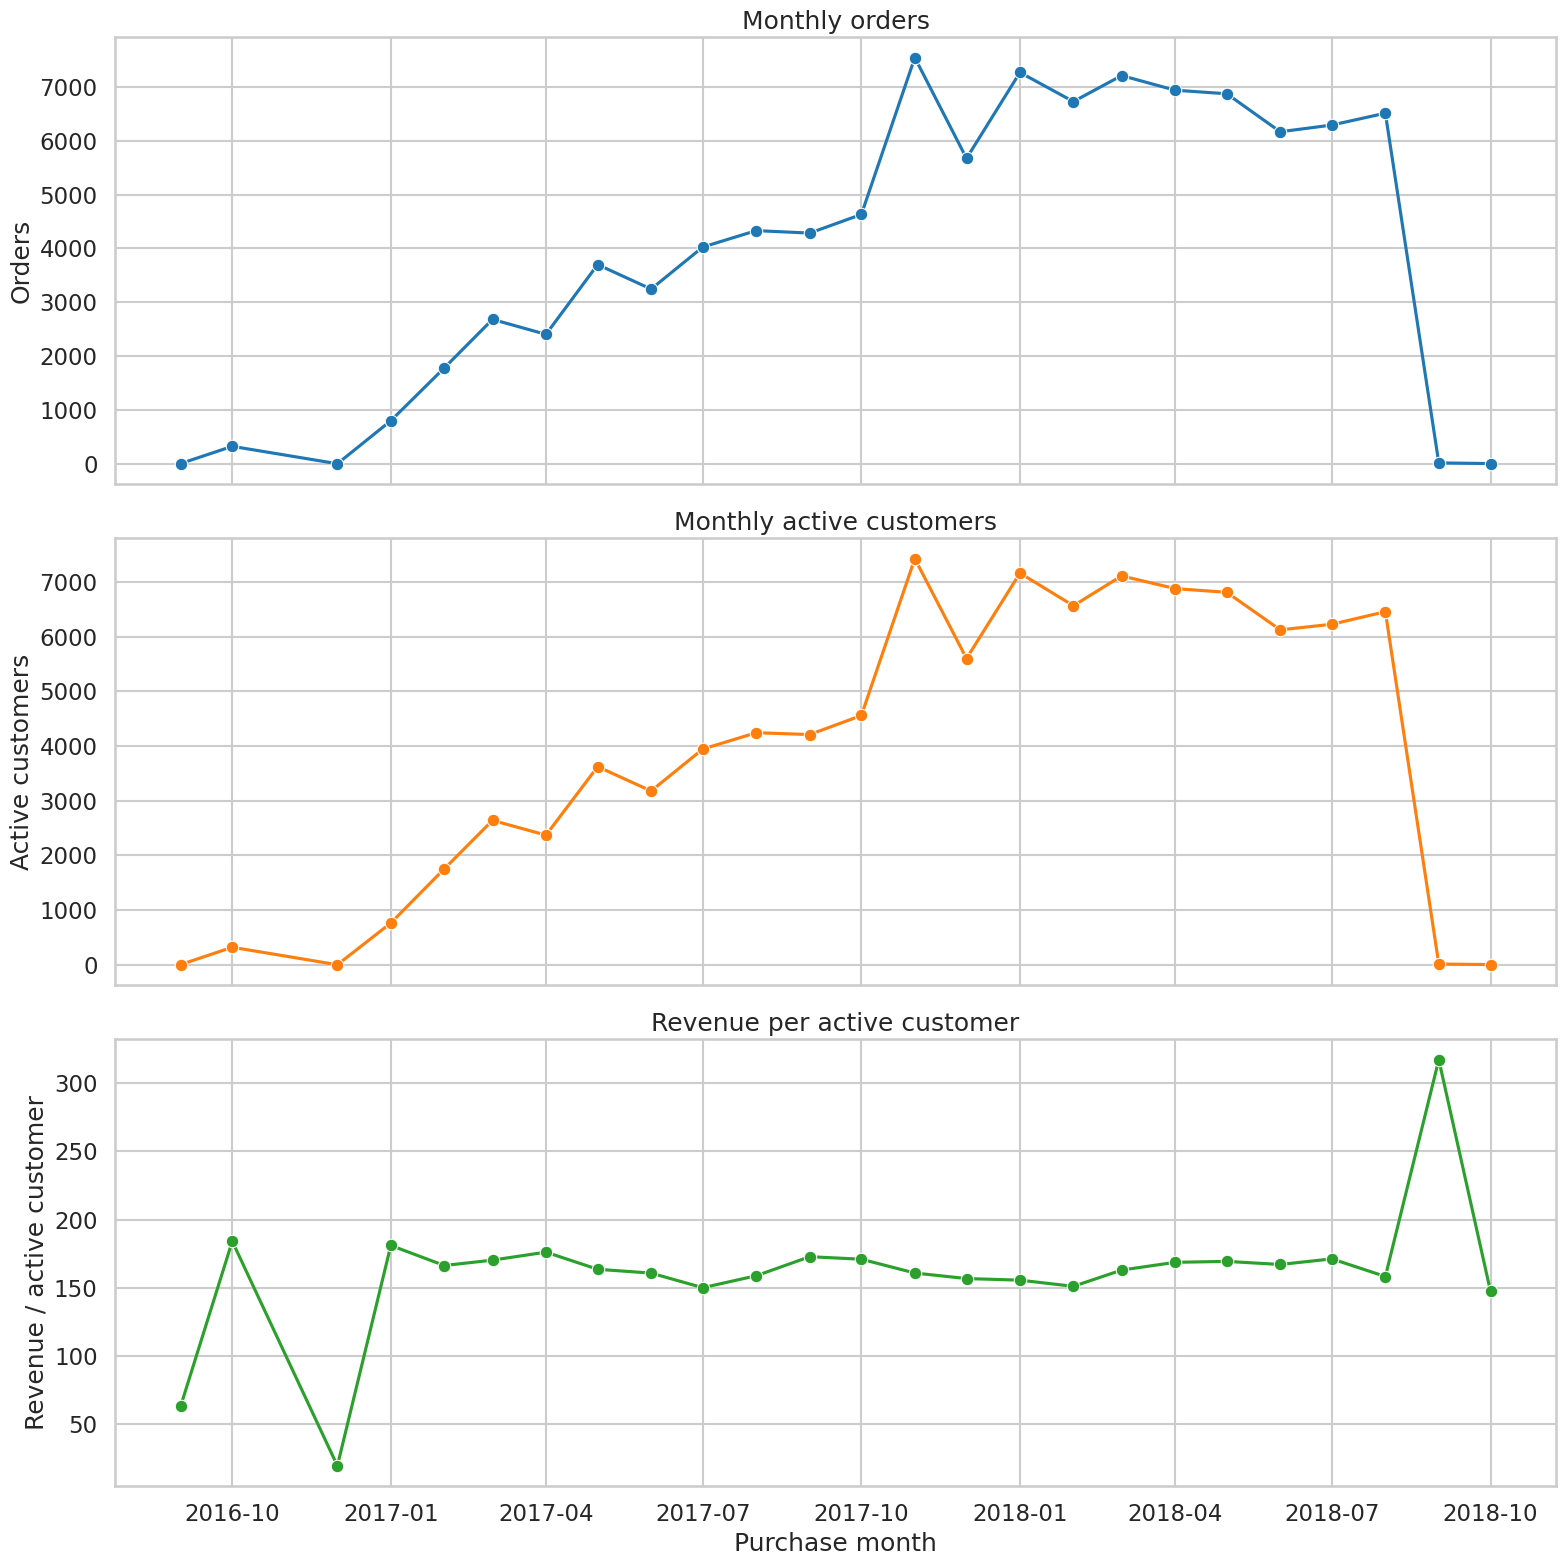

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(16, 16), sharex=True)

sns.lineplot(data=monthly_business_df, x='purchase_month', y='orders_n', marker='o', ax=axes[0], color='#1f77b4')
axes[0].set_title('Monthly orders')
axes[0].set_ylabel('Orders')

sns.lineplot(data=monthly_business_df, x='purchase_month', y='active_customers_n', marker='o', ax=axes[1], color='#ff7f0e')
axes[1].set_title('Monthly active customers')
axes[1].set_ylabel('Active customers')

sns.lineplot(data=monthly_business_df, x='purchase_month', y='revenue_per_active_customer', marker='o', ax=axes[2], color='#2ca02c')
axes[2].set_title('Revenue per active customer')
axes[2].set_ylabel('Revenue / active customer')
axes[2].set_xlabel('Purchase month')

plt.tight_layout()
plt.show()


---
## 2.8. COHORT AND RETENTION VIEW


**What is done**

We construct acquisition cohorts and estimate customer retention by months since first purchase.

**Why it is done**

Cohort analysis helps separate growth effects from true retention behavior and reveals whether churn is concentrated early or later in the customer lifecycle.

**Expected result**

A cohort retention matrix showing how customer activity decays after acquisition.


In [12]:
cohort_df = orders_enriched_df[['customer_unique_id', 'order_id', 'order_purchase_timestamp']].dropna().copy()
cohort_df['order_month'] = cohort_df['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
cohort_df['cohort_month'] = cohort_df.groupby('customer_unique_id')['order_month'].transform('min')
cohort_df['cohort_index'] = (
    (cohort_df['order_month'].dt.year - cohort_df['cohort_month'].dt.year) * 12
    + (cohort_df['order_month'].dt.month - cohort_df['cohort_month'].dt.month)
)

cohort_counts = (
    cohort_df.groupby(['cohort_month', 'cohort_index'])['customer_unique_id']
    .nunique()
    .reset_index(name='customers_n')
)

cohort_sizes = cohort_counts.loc[cohort_counts['cohort_index'] == 0, ['cohort_month', 'customers_n']]
cohort_sizes = cohort_sizes.rename(columns={'customers_n': 'cohort_size'})

cohort_retention = cohort_counts.merge(cohort_sizes, on='cohort_month', how='left')
cohort_retention['retention_rate'] = cohort_retention['customers_n'] / cohort_retention['cohort_size']

cohort_pivot = cohort_retention.pivot(index='cohort_month', columns='cohort_index', values='retention_rate')
cohort_pivot.style.format('{:.1%}')


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01 00:00:00,100.0%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%
2016-10-01 00:00:00,100.0%,nan%,nan%,nan%,nan%,nan%,0.3%,nan%,nan%,0.3%,nan%,0.3%,nan%,0.3%,nan%,0.3%,nan%,0.3%,0.6%,0.6%
2016-12-01 00:00:00,100.0%,100.0%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%
2017-01-01 00:00:00,100.0%,0.4%,0.3%,0.1%,0.4%,0.1%,0.5%,0.1%,0.1%,nan%,0.4%,0.1%,0.8%,0.4%,0.1%,0.1%,0.3%,0.4%,0.1%,nan%
2017-02-01 00:00:00,100.0%,0.2%,0.3%,0.1%,0.4%,0.1%,0.2%,0.2%,0.2%,0.2%,0.1%,0.3%,0.2%,0.2%,0.1%,0.1%,0.1%,0.2%,nan%,nan%
2017-03-01 00:00:00,100.0%,0.5%,0.4%,0.4%,0.3%,0.2%,0.2%,0.3%,0.3%,0.1%,0.4%,0.2%,0.2%,0.1%,0.2%,0.2%,0.1%,0.2%,nan%,nan%
2017-04-01 00:00:00,100.0%,0.6%,0.2%,0.2%,0.3%,0.3%,0.3%,0.3%,0.3%,0.2%,0.3%,0.1%,0.1%,0.0%,0.1%,0.1%,0.2%,nan%,nan%,nan%
2017-05-01 00:00:00,100.0%,0.5%,0.5%,0.4%,0.3%,0.3%,0.4%,0.2%,0.3%,0.3%,0.3%,0.3%,0.3%,0.0%,0.2%,0.3%,nan%,nan%,nan%,nan%
2017-06-01 00:00:00,100.0%,0.5%,0.4%,0.4%,0.3%,0.4%,0.4%,0.2%,0.1%,0.2%,0.3%,0.4%,0.2%,0.1%,0.2%,nan%,nan%,nan%,nan%,nan%


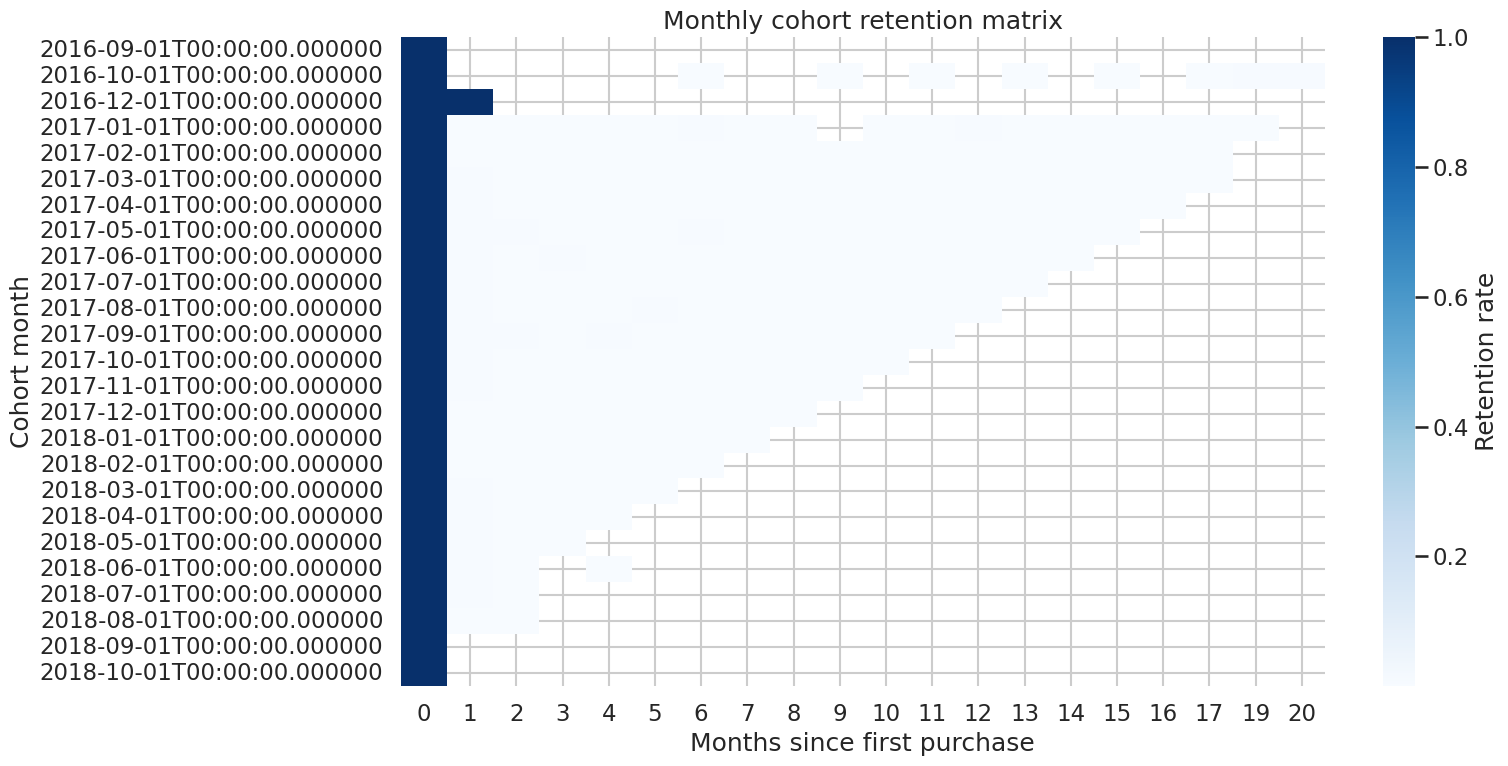

In [13]:
plt.figure(figsize=(16, 8))
sns.heatmap(cohort_pivot, annot=False, cmap='Blues', cbar_kws={'label': 'Retention rate'})
plt.title('Monthly cohort retention matrix')
plt.xlabel('Months since first purchase')
plt.ylabel('Cohort month')
plt.tight_layout()
plt.show()


---
## 2.9. INITIAL CUSTOMER SEGMENTATION


**What is done**

We create a first-pass segmentation using recency, frequency and monetary behavior.

**Why it is done**

This helps identify whether churn is more associated with low-engagement buyers, recently acquired customers or high-value customers that became inactive.

**Expected result**

A practical segmentation lens that can later evolve into engineered model features and retention prioritization rules.


In [14]:
segmentation_df = customer_churn_df.copy()
segmentation_df['recency_days'] = segmentation_df['days_since_last_purchase_at_dataset_end']
segmentation_df['frequency_orders'] = segmentation_df['orders_n']
segmentation_df['monetary_value'] = segmentation_df['total_payment_value']

segmentation_df['recency_band'] = pd.qcut(
    segmentation_df['recency_days'].rank(method='first'),
    q=4,
    labels=['Most recent', 'Recent', 'Stale', 'Most stale']
)
segmentation_df['frequency_band'] = pd.qcut(
    segmentation_df['frequency_orders'].rank(method='first'),
    q=4,
    labels=['Low frequency', 'Mid-low frequency', 'Mid-high frequency', 'High frequency']
)
segmentation_df['monetary_band'] = pd.qcut(
    segmentation_df['monetary_value'].rank(method='first'),
    q=4,
    labels=['Low value', 'Mid-low value', 'Mid-high value', 'High value']
)

segment_summary = (
    segmentation_df
    .groupby(['recency_band', 'frequency_band'], observed=False)
    .agg(
        customers_n=('customer_unique_id', 'count') if 'customer_unique_id' in segmentation_df.columns else ('orders_n', 'count'),
        churn_rate=('churn_90d_flag', 'mean'),
        avg_monetary_value=('monetary_value', 'mean')
    )
    .reset_index()
    .sort_values(['recency_band', 'frequency_band'])
)

segment_summary.head(20)


,recency_band,frequency_band,customers_n,churn_rate,avg_monetary_value
0,Most recent,Low frequency,5971,0.61,162.08
1,Most recent,Mid-low frequency,6032,0.61,165.44
2,Most recent,Mid-high frequency,5921,0.61,168.12
3,Most recent,High frequency,6100,0.61,190.67
4,Recent,Low frequency,6001,1.00,159.91
5,Recent,Mid-low frequency,5963,1.00,159.09
6,Recent,Mid-high frequency,5980,1.00,158.70
7,Recent,High frequency,6080,1.00,177.64
8,Stale,Low frequency,5968,1.00,164.57
9,Stale,Mid-low frequency,5982,1.00,159.13


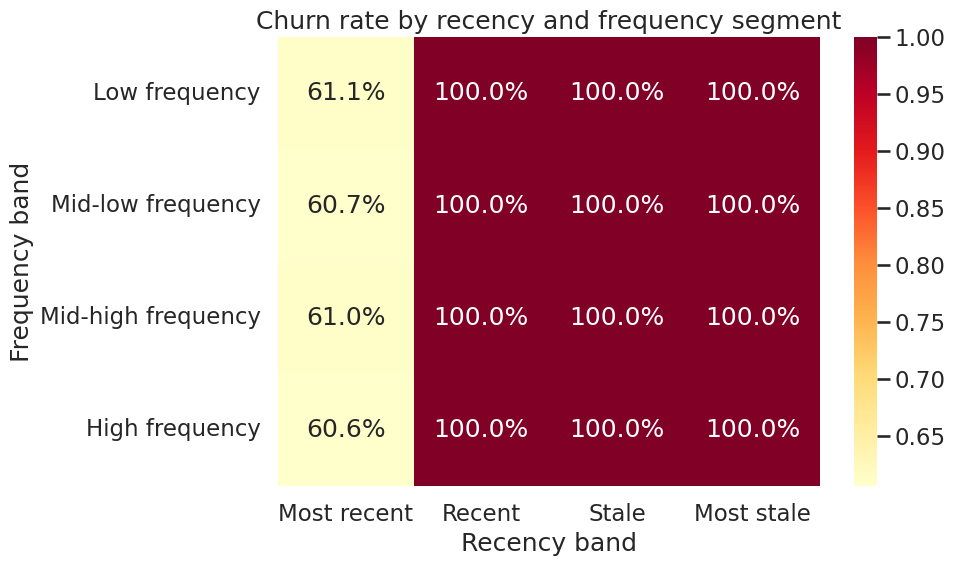

In [15]:
segment_heatmap = segment_summary.pivot(index='frequency_band', columns='recency_band', values='churn_rate')

plt.figure(figsize=(10, 6))
sns.heatmap(segment_heatmap, annot=True, fmt='.1%', cmap='YlOrRd')
plt.title('Churn rate by recency and frequency segment')
plt.xlabel('Recency band')
plt.ylabel('Frequency band')
plt.tight_layout()
plt.show()


---
## 2.10. INSIGHTS FOR FEATURE ENGINEERING


**What is done**

We translate the exploratory findings into explicit implications for NB03 feature engineering.

**Why it is done**

EDA only becomes valuable when it narrows the design space for the predictive layer.

**Expected result**

A shortlist of concrete feature families and modeling precautions justified by the patterns observed in this notebook.


In [16]:
feature_engineering_recommendations = pd.DataFrame({
    'recommendation': [
        'Create recency features at 30, 60 and 90 days.',
        'Engineer customer frequency metrics over rolling time windows.',
        'Capture monetary intensity and order-value variability.',
        'Include cohort-age or customer-age features.',
        'Track review quality and delivered-order ratios as engagement proxies.',
        'Preserve temporal validation because activity is time-dependent.'
    ]
})

feature_engineering_recommendations


,recommendation
0,"Create recency features at 30, 60 and 90 days."
1,Engineer customer frequency metrics over rolli...
2,Capture monetary intensity and order-value var...
3,Include cohort-age or customer-age features.
4,Track review quality and delivered-order ratio...
5,Preserve temporal validation because activity ...


---
## 2.11. RESULTS AND NEXT STEP


**Result of this notebook**

The exploratory layer formalizes an initial 90-day churn label, quantifies its incidence on the eligible customer base and reveals the temporal and behavioral structures that should shape feature engineering. The notebook also separates descriptive customer profiling from temporal/cohort analysis, which is essential for a production-minded churn project.

**Why this matters**

The project can now move from broad exploratory understanding to feature construction with clearer assumptions about recency, retention decay, customer value concentration and temporal validation needs.

**Next step**

NB03 should create customer-level predictive features with rolling windows, cohort-aware temporal attributes and behavior summaries explicitly aligned with the 90-day churn horizon.
